In [19]:
# !pip install pandas matplotlib numpy scipy statsmodels
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as sts
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [20]:
data = pd.read_csv('../data/final.csv')

In [21]:
x = np.log10(data['scored_by']) #
y = data['score']
n = len(x)
t_table = 1.9734

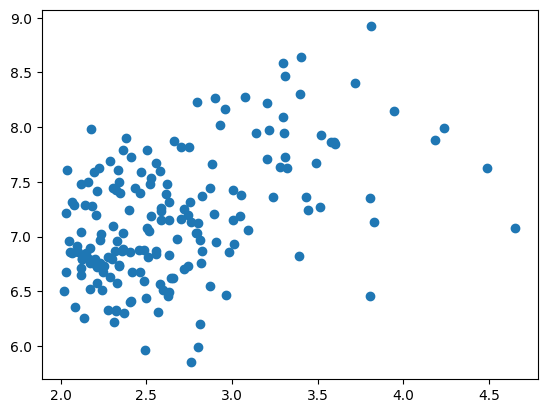

180


In [22]:
plt.scatter(x, y)
plt.show()
print(n)

In [23]:
k, b, cor, k_pval, k_err = sts.linregress(x, y)
s = np.power(y - (b + k * x), 2).sum() / (len(x) - 2)
print("параметры: b1, b0")
print(f'{k:.3f}, {b:.3f}')
print("коэффициент корреляцмм и коэффициент детерминации:")
print(f'{cor:.3f}, {(cor ** 2):.3f}')
print('критерий Стьюдента для b1:')
print(f'p-value = {k_pval:.3f}, tрасч = {k / k_err:.3f}')
print('критерий Стьюдента для b0:')
b_err = (s * np.power(x, 2).sum() / n / np.power(x - x.mean(), 2).sum()) ** 0.5
print(f'tтабл = {t_table:.3f}, tрасч = {b / b_err:.3f}')
print('интервальная оценка для b1')
print(f"b1 = {k:.3f} +- {t_table * k_err:.3f}")
print('интервальная оценка для b0')
print(f'b0 = {b:.3f} +- {t_table * b_err:.3f}')

параметры: b1, b0
0.514, 5.797
коэффициент корреляцмм и коэффициент детерминации:
0.466, 0.217
критерий Стьюдента для b1:
p-value = 0.000, tрасч = 7.031
критерий Стьюдента для b0:
tтабл = 1.973, tрасч = 29.130
интервальная оценка для b1
b1 = 0.514 +- 0.144
интервальная оценка для b0
b0 = 5.797 +- 0.393


In [24]:
modell = sm.OLS(x, y).fit()
modell = ols('Y ~ X', pd.DataFrame({'X' : x, 'Y' : y})).fit()
ta = sm.stats.anova_lm(modell, typ=2)
print(ta.round(3))
gq_f, gq_p, gq_ord = sm.stats.diagnostic.het_goldfeldquandt(y, sm.add_constant(x))##
print('\nТест Голдфелда-Квандта:')
print(f'F-статистика = {gq_f:.3f}, p-value = {gq_p:.3f}')
print('предсказание')
yp = b + k * x.mean() * 1.05
print(f'yp = {yp:.3f}')
print('Доверительный интервал:')
print(f'yp = {yp:.3f} +- {t_table * (s * (1 / n + 1 + (0.05 * x.mean()) ** 2) / np.power(x - x.mean(), 2).sum()) ** 0.5:.3f}')

          sum_sq     df       F  PR(>F)
X         12.941    1.0  49.431     0.0
Residual  46.599  178.0     NaN     NaN

Тест Голдфелда-Квандта:
F-статистика = 1.465, p-value = 0.038
предсказание
yp = 7.239
Доверительный интервал:
yp = 7.239 +- 0.146
